<a href="https://colab.research.google.com/github/elean23/2025-webinar-ml-with-python/blob/main/Modulo6Capsula3_abiertaUGR_english.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

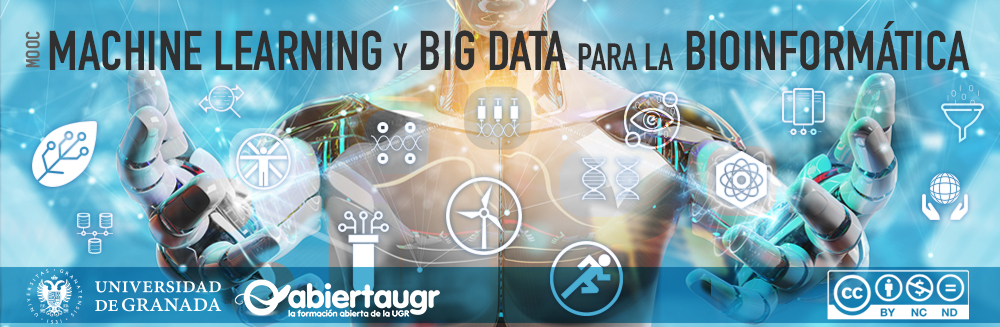

## **Module 6 - Unsupervised learning: clustering and association rules**
## **6.3 Association Rules (ARs)**

**Authors**:

*By* Dra. Elena Ruiz Sánchez

Developer at Revvity.

*By* Dr. Jesús Alcalá Fernández

Full Professor at the University of Granada, Andalusian Interuniversity Institute in Data Science and Computational Intelligence (DasCI).

## **INDEX**


In this *notebook*:
1. We discover examples of variables that we can use to extract associations and to learn more about distinct groups of patients.
2. We learn how to transform our dataset into a set of transactions.
3. We examine how to decide the support and confidence thresholds for our problem using graphs.
4. We establish how to use the [*MLXTEND*](http://rasbt.github.io/mlxtend/) library to extract frequent itemsets and association rules.
5. We study different ways to analyze our rules based on several types of graphs.
    
Contents:
1. Description of the problem
2. Reading and processing the data
3. Obtaining frequent itemsets
4. Extraction and analysis of association rules

## **INSTALLING LIBRARIES**

In [1]:
# Installing mlxtend library
!pip install --upgrade mlxtend # Exclamation point ! is necessary because we are in a notebook
#pip install --upgrade mlxtend # Use this line instead if you want to install mlxtend outside a notebook

In [2]:
# Installing rpy2 library to combine R and Python
#!apt-get update
#!apt-get install r-base
!pip install rpy2==3.5.1
# Loading rpy2.ipython extension
%load_ext rpy2.ipython

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.7/201.7 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rpy2: filename=rpy2-3.5.1-cp312-cp312-linux_x86_64.whl size=316568 sha256=b96cda1feeb2744071e55c49fec08c2d9504707edfc8421e6cd44cdd4d3d62f5
  Stored in directory: /root/.cache/pip/wheels/00/26/d5/d5e8c0b039915e785be870270e4a9263e5058168a03513d8cc
Successfully built rpy2
  Attempting uninstall: rpy2
    Found existing installation: rpy2 3.5.17
    Uninstalling rpy2-3.5.17:
      Successfully uninstalled rpy2-3.5.17


In [3]:
# Installing R libraries that we will need later on
%%R
# Installing chorddiag library from a GitHub repository
devtools::install_github("mattflor/chorddiag")
# Installing RColorBrewer library to use several color palettes
install.packages('RColorBrewer')

ℹ The package "remotes" is required.
✖ Would you like to install it?

1: Yes
2: No

Selection: 1

 Found  1  deps for  0/1  pkgs [⠋] Resolving standard (CRAN/BioC) packages
 Found  1  deps for  0/1  pkgs [⠙] Resolving standard (CRAN/BioC) packages
Checking for 8 new metadata files
 Found  1  deps for  0/1  pkgs [⠹] Resolving standard (CRAN/BioC) packages
⠋ Updating metadata database [0/8] | Downloading [0 B / 0 B]
 Found  1  deps for  0/1  pkgs [⠸] Resolving standard (CRAN/BioC) packages
⠙ Updating metadata database [0/8] | Downloading [0 B / 0 B]
 Found  1  deps for  0/1  pkgs [⠼] Resolving standard (CRAN/BioC) packages
 Found  1  deps for  0/1  pkgs [⠴] Resolving standard (CRAN/BioC) packages
⠹ Updating metadata database [0/8] | Downloading [192.10 kB / 3.54 MB]
 Found  1  deps for  0/1  pkgs [⠦] Resolving standard (CRAN/BioC) packages
⠸ Updating metadata database [0/8] | Downloading [536.16 kB / 3.54 MB]
 Found  1  deps for  0/1  pkgs [⠧] Resolving standard (CRAN/BioC) packages
⠼ Up

These packages have more recent versions available.
It is recommended to update all of them.
Which would you like to update?

1: All                          
2: CRAN packages only           
3: None                         
4: fs    (2.0.1 -> 2.1.0) [CRAN]
5: cli   (3.6.5 -> 3.6.6) [CRAN]
6: rlang (1.1.7 -> 1.2.0) [CRAN]

Enter one or more numbers, or an empty line to skip updates: 1
fs    (2.0.1 -> 2.1.0) [CRAN]
cli   (3.6.5 -> 3.6.6) [CRAN]
rlang (1.1.7 -> 1.2.0) [CRAN]



(as ‘lib’ is unspecified)





	‘/tmp/RtmpkmflGu/downloaded_packages’



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpkmflGu/remotes34b4cd03d8e/mattflor-chorddiag-1688d72/DESCRIPTION’ ... OK
* preparing ‘chorddiag’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
Omitted ‘LazyData’ from DESCRIPTION
* building ‘chorddiag_0.1.3.tar.gz’



(as ‘lib’ is unspecified)

(as ‘lib’ is unspecified)







	‘/tmp/RtmpkmflGu/downloaded_packages’



##**1. INTRODUCTION TO THE PROBLEM<a id="sec:intro"></a>**

We have already seen how, even when starting from the same problem, we can apply different machine learning techniques according to the type of task we are interested in solving. In the previous capsule we saw that clustering can be used to obtain different groups of patients based on gene expression information. The authors of the original study performed a clustering analysis of this nature and obtained three groups of patients with significantly different survival times. In this capsule we will focus on using association rules (ARs) to complement the information about these patient groups and to characterize potential subgroups.

To accomplish this, we will use data other than gene expression data to obtain more information about the characteristics of the patients in each of these groups and to test whether differences in the expression of certain genes are also associated with differences in other variables. Discovering whether such connections exist between variables and identifying them helps us to better understand the disease under study. They may also allow us to identify previously unknown relationships that can serve as a basis for new hypotheses to improve the prevention, detection, or treatment of the disease.

Specifically, here we will work with 6 different variables. One of them indicates the cluster in which the instance was included based on gene expression levels, while the other 5 represent variables that can provide us with additional information about the characteristics of the patients included in each cluster. These variables are:

*   MUTATIONSUBTYPES: the development of targeted therapies for patients with specific mutations was a major success in clinical practice. Therefore, it is useful to understand whether any significant mutations have been found in certain genes for each melanoma type. Thus, this variable indicates whether any of the most frequent types of mutations were found among the patients analyzed; it has 4 possible values:
  * "*BRAF_Hotspot_Mutants*": *BRAF* gene hot-spot mutations are present; these types of mutations are found in 52% of the instances and are the most frequent in the dataset.
  * "*RAS_Hotspot_Mutants*": indicates the presence of *RAS* gene hot-spot mutations; these are the second most frequently encountered mutation types.
  * "*NF1_Any_Mutants*": the third mutation type most often observed, and present in 14% of cases, is in the *NF1* gene.
  * "*Triple_WT*": this subtype is defined as a heterogeneous group that includes instances in which no *BRAF*, *RAS*, or *NF1* mutations are present.
*   UV-signature: ultraviolet radiation plays an important mutagenic role in melanoma. This variable has two possible values: "UV signature" or "not UV signature". Instances for which C>T transitions represent more than 60% or CC>TT mutations represent more than 5% of the total mutation load are marked with the "UV signature" value. Instances that do not meet this criteria are assigned the "not UV" value.
*   RNASEQ-CLUSTER_CONSENHIER: indicates the cluster assigned to the instance in the clustering process we saw in the previous capsule and whose results we will now try to complement by using ARs. This parameter can be assigned 1 of 3 three different values, each representing 1 of the possible clusters: "immune", "keratin", or "MITF-low".
*   MethTypes.201408: this variable is also the result of a clustering process, in this case applied to the methylation values for a series of CpG loci. As in the previous case, each of the values corresponds to a cluster. In this case there are 4 clusters: "CpG island-methylated", "hyper-methylated", "normal-like", and "hypo-methylated". The instances of "CpG island-methylated" cluster have high methylation levels for more CpG loci, and those of the "hypo-methylated" cluster have the lowest methylation values.
*   MIRCluster: is another variable resulting from a clustering process. This time applied to microRNA sequencing data. In this case there are 4 possible clusters: "MIR.type.1", "MIR.type.2", "MIR.type.3", or "MIR.type.4".
*   LYMPHOCYTE.SCORE: this metric is calculated as a function of lymphocyte distribution and density. Both these factors are evaluated by experts and scored on a scale [0,3], with 0 indicating the absence of lymphocytes in both cases and 3 indicating the presence of lymphocytes in most of the tissue (distribution), or a high concentration (in the case of density). This variable is calculated as the sum of both scores and therefore, takes integer values in the range [0,6].

This is the analysis approach we will take in this capsule. However, ARs could be useful in other approaches within the context of the melanoma cancer data set we will be working with throughout the course. The group of variables we will work with, as well as the technique we will choose, will depend on our objectives and the characteristics of the variables in question.

Here we will focus on the 6 variables referred to above and will implement the steps required to identify the frequent itemsets, extract the ARs, and analyze them. As part of this latter step, we will perform a cluster analysis of the rules, focusing on certain variables that are of interest to us. For instance, we will study rules in which certain mutation subtypes appear to see what conclusions we can draw about how they relate to the other variables.

##**2. READING AND PROCESSING THE DATA<a id="sec:leer"></a>**

###**2.1 Reading the dataset**

The first step is to read our dataset so that we can work with it in Python. To read the file we are going to use the *Pandas* library.

In [4]:
# Importing pandas library with alias 'pd'
import pandas as pd

# Saving link to our data in variable 'url_datos'
url_datos = 'https://drive.google.com/uc?id=1VF3MqQ3J7GBc527ClL2IgJ23XTc5-hX7'

# Using read_csv method to read a file in CSV format
conjunto_datos = pd.read_csv(url_datos, delimiter=',', na_values='-')

# Printing the columns (variables) in the data we just read
print('Variables read:')
print(', '.join(conjunto_datos.columns))

Variables read:
MUTATIONSUBTYPES, UV-signature, RNASEQ-CLUSTER_CONSENHIER, MethTypes.201408, MIRCluster, LYMPHOCYTE.SCORE


The dataset read is part of one of the data files published by the authors of the original study, although it includes many more variables than the 6 we will use in this notebook.

###**2.2 Transformation into a transaction set**

This dataset contains a fixed number of 6 variables and each instance (corresponding to a tissue sample from a given patient) contains a value for each of those variables. To verify this, we can look at the first few instances of our dataset:

In [5]:
# So all the variables are displayed in screen...
pd.set_option('display.max_columns', 6)
print('First 5 instances of the dataset:')
# Printing the first 5 instances of the dataset
print(conjunto_datos.head())
# Resetting default value
pd.reset_option('display.max_columns')

First 5 instances of the dataset:
       MUTATIONSUBTYPES  UV-signature RNASEQ-CLUSTER_CONSENHIER  \
0  BRAF_Hotspot_Mutants  UV signature                   keratin   
1   RAS_Hotspot_Mutants  UV signature                   keratin   
2  BRAF_Hotspot_Mutants  UV signature                   keratin   
3   RAS_Hotspot_Mutants  UV signature                   keratin   
4             Triple_WT        not UV                    immune   

        MethTypes.201408  MIRCluster  LYMPHOCYTE.SCORE  
0            normal-like  MIR.type.3               2.0  
1  CpG island-methylated  MIR.type.2               4.0  
2            normal-like  MIR.type.1               5.0  
3        hypo-methylated  MIR.type.2               2.0  
4  CpG island-methylated  MIR.type.2               6.0  


ARs were originally applied to categorical variables (e.g., whether a certain product was purchased at a supermarket or not). However, numerical variables can also be incorporated into our AR analyses, for instance by dividing the values of the variable into intervals, assigning them a name (e.g., "high", "medium", or "low"), and treating them as categories. In fact, if the numerical variable can only be assigned a few values, such as in the case of the "LYMPHOCYTE.SCORE" variable.

In [6]:
print('Distinct values for each of the variables:\n')
for col in conjunto_datos.columns:
  print('*%s-> %s' % (col, ', '.join(conjunto_datos.loc[conjunto_datos[col].notnull(), col].sort_values().unique().astype(str))))


Distinct values for each of the variables:

*MUTATIONSUBTYPES-> BRAF_Hotspot_Mutants, NF1_Any_Mutants, RAS_Hotspot_Mutants, Triple_WT
*UV-signature-> UV signature, not UV
*RNASEQ-CLUSTER_CONSENHIER-> MITF-low, immune, keratin
*MethTypes.201408-> CpG island-methylated, hyper-methylated, hypo-methylated, normal-like
*MIRCluster-> MIR.type.1, MIR.type.2, MIR.type.3, MIR.type.4
*LYMPHOCYTE.SCORE-> 0.0, 2.0, 3.0, 4.0, 5.0, 6.0


“LYMPHOCYTE.SCORE” variable only has 6 possible values, so we can directly treat each one as a category as we do with the values of the other variables.

As we saw earlier in the course, it is common to work with items and transactions in the field of ARs. To work with our dataset in terms of items and transactions we must make a small adjustment to its format. In this case, items will become pairs (variable, value) and each instance will become a transaction containing a list of pairs (variable, value).

When working in Python, this transaction set will be represented as a table with a column for each possible item and with each row taking the value 1 for items (columns) contained in the transaction and 0 for those that were not.

In [7]:
# Using get_dummies methods to generate a transaction set
transacciones = pd.get_dummies(conjunto_datos, columns=conjunto_datos.columns, prefix_sep='=') # Ignora los valores perdidos a no ser que se le indique dummy_na=True

# In the transaction set generated by get_dummies each pair
# (variable, value) is represented with the format variable=value
transacciones.head()

,MUTATIONSUBTYPES=BRAF_Hotspot_Mutants,MUTATIONSUBTYPES=NF1_Any_Mutants,MUTATIONSUBTYPES=RAS_Hotspot_Mutants,MUTATIONSUBTYPES=Triple_WT,UV-signature=UV signature,UV-signature=not UV,RNASEQ-CLUSTER_CONSENHIER=MITF-low,RNASEQ-CLUSTER_CONSENHIER=immune,RNASEQ-CLUSTER_CONSENHIER=keratin,MethTypes.201408=CpG island-methylated,...,MIRCluster=MIR.type.1,MIRCluster=MIR.type.2,MIRCluster=MIR.type.3,MIRCluster=MIR.type.4,LYMPHOCYTE.SCORE=0.0,LYMPHOCYTE.SCORE=2.0,LYMPHOCYTE.SCORE=3.0,LYMPHOCYTE.SCORE=4.0,LYMPHOCYTE.SCORE=5.0,LYMPHOCYTE.SCORE=6.0
0,True,False,False,False,True,False,False,False,True,False,...,False,False,True,False,False,True,False,False,False,False
1,False,False,True,False,True,False,False,False,True,True,...,False,True,False,False,False,False,False,True,False,False
2,True,False,False,False,True,False,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
3,False,False,True,False,True,False,False,False,True,False,...,False,True,False,False,False,True,False,False,False,False
4,False,False,False,True,False,True,False,True,False,True,...,False,True,False,False,False,False,False,False,False,True


Now we have our dataset in a format in which we can work on items and transactions, we will use it as input information for the algorithms responsible for discovering frequent itemsets.

The items are represented in the variable=value format so that the itemsets and rules we generate in the following steps will be more easily readable.

##**3. OBTAINING FREQUENT ITEMSETS<a id="sec:freq_itemsets"></a>**

###**3.1 Explore items**

The next step towards the extraction of ARs is the identification of frequent itemsets. We must specify the minimum support required to decide whether an itemset is considered frequent. As an initial estimation, we can say that we will normally choose support in the range (0, 0.2], but this value can vary a lot depending on the data we are working with. Knowing the frequency with which each of the items appears in the dataset can help us a little in selecting the support. Even so, it is likely that we will have to test some different values before deciding upon an appropriate option

If you need to review concepts such as frequent itemsets or support, remember that you can refer both to Capsule 1 of this current module and Capsule 3 of Module 3 (*Unsupervised learning*) at any time.

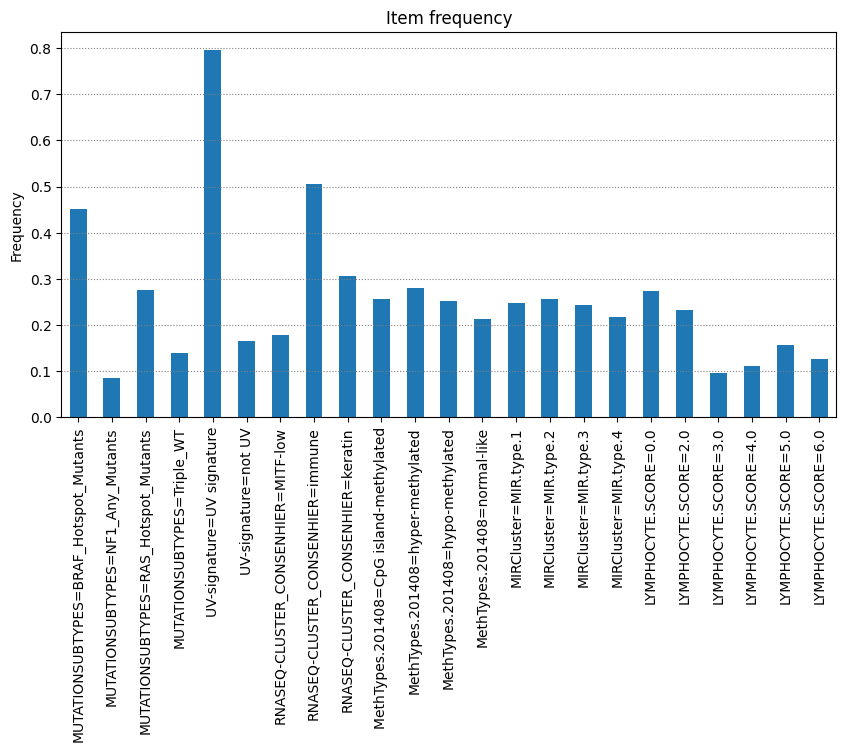

In [8]:
# Importing matplotlib.pyplot library with alias plt
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,5))
# Computing the frequency of each item
item_freqs = transacciones.sum()/len(transacciones)
# Representing such frequencies in a plot
item_freqs.plot(kind='bar', title='Item frequency')
plt.ylabel('Frequency')
plt.grid(axis='y', ls=':', color='grey')
plt.show()

Here we should note the presence of a substantial number of items whose frequency is less than 0.2. The less frequent items have a support level below 0.1. It is important to understand the significance of support and to consider the frequencies of items in our dataset when deciding on a minimum support threshold. In this case, if we were to set a support threshold of 0.2, we know that all the items that appear in fewer than 20% of the transactions will be automatically discarded as frequent itemsets. Therefore, any superset that could include them must also be discarded as a frequent itemset and no rules including such an item can be generated.

For instance, if the item LYMPHOCYTE.SCORE=5.0 with a support of 0.1561 is not a frequent itemset, then nor can LYMPHOCYTE.SCORE=5.0, RNASEQ-CLUSTER_CONSENHIER=immune) or any other itemset that includes the item LYMPHOCYTE.SCORE=5.0. This is because these other itemsets can appear in the dataset at most as many times as LYMPHOCYTE.SCORE=5.0 appears.

In [9]:
print('Frequency of each item:')
print(transacciones.sum()/len(transacciones))

Frequency of each item:
MUTATIONSUBTYPES=BRAF_Hotspot_Mutants     0.450450
MUTATIONSUBTYPES=NF1_Any_Mutants          0.084084
MUTATIONSUBTYPES=RAS_Hotspot_Mutants      0.276276
MUTATIONSUBTYPES=Triple_WT                0.138138
UV-signature=UV signature                 0.795796
UV-signature=not UV                       0.165165
RNASEQ-CLUSTER_CONSENHIER=MITF-low        0.177177
RNASEQ-CLUSTER_CONSENHIER=immune          0.504505
RNASEQ-CLUSTER_CONSENHIER=keratin         0.306306
MethTypes.201408=CpG island-methylated    0.255255
MethTypes.201408=hyper-methylated         0.279279
MethTypes.201408=hypo-methylated          0.252252
MethTypes.201408=normal-like              0.213213
MIRCluster=MIR.type.1                     0.246246
MIRCluster=MIR.type.2                     0.255255
MIRCluster=MIR.type.3                     0.243243
MIRCluster=MIR.type.4                     0.216216
LYMPHOCYTE.SCORE=0.0                      0.273273
LYMPHOCYTE.SCORE=2.0                      0.231231
LYMPHOC

In this capsule we will work with a minimum support of 0.015. This support is a low enough for all the basic itemsets (1−itemsets) to be considered frequent and, therefore, for them to potentially become part of an AR. It is also low enough to allow some diversity in longer itemsets. This minimum support simultaneously allows sets of itemsets representing excessively specific cases—for example, those that occur for a single transaction (a single patient)—to be excluded from consideration as frequent itemsets.

We encourage you to experiment with different support thresholds and see how the number, length, and content of frequent itemsets and the ARs extracted from them change.

###**3.2 The FP-Growth algorithm for frequent itemset detection**

**FP-Growth** is an algorithm used to identify frequent itemsets in a dataset given a minimum level of support. The main advantage of FP-Growth is its efficiency. It uses a tree structure to represent the dataset in a compressed form and this allows it to be more efficient at finding frequent itemsets compared to other techniques.
We will use the [MLXTEND](http://rasbt.github.io/mlxtend/) library to apply FP-Growth. MLXTEND is a Python library that includes several data science and machine learning tools and methods in addition to AR extraction tools. However, in this capsule we will exclusively focus on the functionality of MLXTEND for [frequent itemsets and ARs](http://rasbt.github.io/mlxtend/api_subpackages/mlxtend.frequent_patterns/).

Among other options, MLXTEND includes an implementation of the [FP-Growth algorithm](http://rasbt.github.io/mlxtend/user_guide/frequent_patterns/fpgrowth/).

In [10]:
# Importing FP-Growth from MLXTEND
from mlxtend.frequent_patterns import fpgrowth

# Applying FP-growth passing minimum support threshold as parameter
# 'max_len' parameter sets the maximum length for the itemsets
itemsets_frecuentes = fpgrowth(transacciones.astype('bool'), min_support=0.015, use_colnames=True, max_len=4)

print('%d frequent itemsets identified.' % (len(itemsets_frecuentes)))

965 frequent itemsets identified.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In addition to selecting the minimum support threshold, we must also provide a maximum length of 4 items for the itemsets. Limiting the maximum length of itemsets allows rules to be less complex, making their analysis somewhat simpler. We can look at the contents of *itemsets_frecuentes* to check the output format returned by FP-Growth.

In [11]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Showing the first 5 rows of freq_itemsets
print(itemsets_frecuentes.head())

    support                                           itemsets
0  0.795796             frozenset({UV-signature=UV signature})
1  0.450450  frozenset({MUTATIONSUBTYPES=BRAF_Hotspot_Mutan...
2  0.306306     frozenset({RNASEQ-CLUSTER_CONSENHIER=keratin})
3  0.243243                 frozenset({MIRCluster=MIR.type.3})
4  0.231231                  frozenset({LYMPHOCYTE.SCORE=2.0})


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

As we can see, *itemsets_frecuentes* has two columns: the first one contains the support of a frequent itemset and the second one presents the frequent itemset itself. Looking only at these first 5 rows of frequent *itemsets_frecuentes* we might think that all the ones found had a length of 1 (i.e., they comprise only 1 item). However, if we consult the last 5 rows, things change.

In [12]:
# Showing the last 5 rows of freq_itemsets
print(itemsets_frecuentes.tail())

      support                                           itemsets
960  0.021021  frozenset({MIRCluster=MIR.type.2, UV-signature...
961  0.021021  frozenset({RNASEQ-CLUSTER_CONSENHIER=immune, M...
962  0.018018  frozenset({MethTypes.201408=hypo-methylated, R...
963  0.015015  frozenset({MethTypes.201408=hypo-methylated, U...
964  0.015015  frozenset({MethTypes.201408=hypo-methylated, R...


The frequent itemsets are ordered so that those formed by 1 item (those with higher supports) appear in the first rows, while more complex itemsets appear in the last rows. As we add items to the itemsets, the support is reduced because we are adding more elements that must be in the transaction at the same time.

To get a better general idea of the lengths of the frequent itemsets identified by FP-Growth we can look up the length of each of the frequent itemsets, count how many itemsets there are with each length, and represent this graphically.

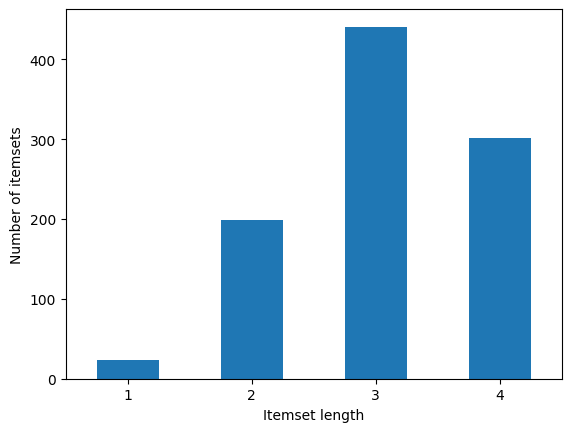

In [13]:
# Counting how many frequent itemsets of each length have been found
itemsets_frecuentes_por_longitud = itemsets_frecuentes['itemsets'].apply(len).value_counts().sort_index()

# Creating a barchart to represent the number of itemsets by their length
fig = plt.figure()
ax = fig.add_subplot(111)
itemsets_frecuentes_por_longitud.plot(kind='bar', ax=ax, rot=0)
ax.set_xlabel('Itemset length')
ax.set_ylabel('Number of itemsets')
plt.show()

##**4. EXTRACTION AND ANALYSIS OF ASSOCIATION RULES<a id="sec:reglas"></a>**

###**4.1 From frequent itemsets to association rules**

Once we have used the FP-Growth algorithm to identify the frequent itemsets, we can now generate ARs from them with a certain minimum confidence. To do so, we will continue working with the MLXTEND library, which also has functionality to generate [association rules](http://rasbt.github.io/mlxtend/user_guide/frequent_patterns/association_rules/) from a list of frequent itemsets. We will set the minimum confidence threshold to 0.85. Like the support threshold, this will depend on the problem on which we are working. Different thresholds are usually tested before choosing the one that seems most appropriate.

However, confidence thresholds that are too low are not normally useful because the implication A→C that represents the rule is fulfilled on most occasions in which A appears. In general, it is desirable to choose confidence thresholds equal to or greater than 0.75 to ensure that the rule is violated in no more than 25% of the cases, which is a considerably high margin of error.

In [14]:
# Importing association_rules method from MLXTEND library
from mlxtend.frequent_patterns import association_rules

# Establishing minimum confidence threshold at 0.85
reglas_asociacion = association_rules(itemsets_frecuentes, metric="confidence", min_threshold=0.85)

print('%d rules generated.' % (len(reglas_asociacion)))

317 rules generated.


As we did with the FP-Growth result we can now look at *reglas_asociacion*.

In [15]:
# So all the variables can be displayed...
pd.set_option('display.max_columns', 6)
print('First 5 rules:')
print(reglas_asociacion.head())
pd.reset_option('display.max_columns')

First 5 rules:
                                         antecedents  \
0  frozenset({MUTATIONSUBTYPES=BRAF_Hotspot_Mutan...   
1  frozenset({RNASEQ-CLUSTER_CONSENHIER=immune, M...   
2  frozenset({RNASEQ-CLUSTER_CONSENHIER=keratin, ...   
3  frozenset({MIRCluster=MIR.type.3, MUTATIONSUBT...   
4  frozenset({RNASEQ-CLUSTER_CONSENHIER=keratin, ...   

                              consequents  antecedent support  ...   jaccard  \
0  frozenset({UV-signature=UV signature})            0.450450  ...  0.487455   
1  frozenset({UV-signature=UV signature})            0.231231  ...  0.261993   
2  frozenset({UV-signature=UV signature})            0.102102  ...  0.111524   
3  frozenset({UV-signature=UV signature})            0.084084  ...  0.089219   
4  frozenset({UV-signature=UV signature})            0.033033  ...  0.037594   

   certainty  kulczynski  
0   0.542941    0.709937  
1   0.618411    0.595001  
2   0.423875    0.497780  
3   0.300420    0.473854  
4   0.554813    0.473413  

[5 r

*reglas_asociacion* has 9 columns and contains a total of 317 rules. Two of the columns, antecedents and consequents, are dedicated to storing the two itemsets that form the antecedent and consequent of the rule, respectively. The other 7 columns contain values for different quality metrics of the rule.

###**4.2 Initial assessment of the extracted rules**


The number of rules found (317) can be a bit overwhelming at first. So, where do we start? How do we know which rules might be most interesting? Which quality metric should we look at? Let’s go step by step.

We can start by querying how many items form the antecedents and consequents of the ARs obtained. Because we limited the length of frequent itemsets to a maximum of 4 items, the antecedent of the rules will have at most 3 items given that at least one of them must be the consequent.

In [16]:
print('Number of rules by antecedent length:')
print(reglas_asociacion['antecedents'].apply(len).value_counts().sort_index())

print('Number of rules by consequent length:')
print(reglas_asociacion['consequents'].apply(len).value_counts().sort_index())

Number of rules by antecedent length:
antecedents
1      6
2    103
3    208
Name: count, dtype: int64
Number of rules by consequent length:
consequents
1    314
2      3
Name: count, dtype: int64


As we can see, indeed, the maximum length of the antecedents is 3 items and only 6 rules have a single item as the antecedent. Regarding the consequent, some rules have more than one item in the consequent, but these are a clear minority. Next, we will see the consequents of the rules and in how many ARs they each appear:

In [17]:
print('Number of rules with each consequent:')
print(reglas_asociacion['consequents'].value_counts())

Number of rules with each consequent:
consequents
frozenset({UV-signature=UV signature})                                      232
frozenset({RNASEQ-CLUSTER_CONSENHIER=immune})                                46
frozenset({RNASEQ-CLUSTER_CONSENHIER=keratin})                               14
frozenset({LYMPHOCYTE.SCORE=0.0})                                             5
frozenset({MUTATIONSUBTYPES=BRAF_Hotspot_Mutants})                            5
frozenset({UV-signature=not UV})                                              4
frozenset({MUTATIONSUBTYPES=Triple_WT})                                       4
frozenset({UV-signature=UV signature, RNASEQ-CLUSTER_CONSENHIER=immune})      3
frozenset({MUTATIONSUBTYPES=RAS_Hotspot_Mutants})                             2
frozenset({MIRCluster=MIR.type.2})                                            1
frozenset({MIRCluster=MIR.type.4})                                            1
Name: count, dtype: int64


The remarkably high number of rules in which the consequent is the itemset (UV-signature=UV signature) is particularly striking. If we return to the bar chart representing the frequency of each of the itemsets that we generated at the beginning of section 3 in this notebook, we can see that the itemset *UV-signature=UV signature* is present in practically 80% of the transactions.

<figure>
<center>
<img src='https://drive.google.com/uc?id=1x1CeeCVccpqKxyY8SklT3XG9dOv-icI6' width=600/>
<figcaption>Frequency of each one of the items in the dataset</figcaption></center>
</figure>


The confidence of a rule is a good starting point but also has its limitations. The algorithm generates rules with a confidence higher than the indicated threshold (0.85 in our case). Therefore, some irrelevant rules with a confidence exceeding the threshold were generated because they had an item with a high level of support in the consequent. Remember that in Capsule 1 of this module we saw that the confidence metric presented this problem by not considering the support of the consequent in the calculation.

To avoid these rules, we recommend considering other metrics such as *lift* or *leverage* to complement the use of confidence to evaluate the quality of ARs:

*	*Lift*: evaluates whether the consequent is more common in those transactions where the antecedent appears than in the dataset in general.
*	*Leverage*: checks if the support of the rule is greater or smaller than it would be if the antecedent and consequent were independent.

Both metrics consider the support of the consequent and help to check if a rule has a high level of confidence because A→C is indeed true, or if the confidence is high simply because the consequent is very frequent. To be of good quality, rules must have a lift value exceeding 1 and a leverage greater than 0. Thus, we filter our rules to ensure that that we retain only those that meet these 2 conditions:

In [18]:
reglas_asociacion = reglas_asociacion.loc[(reglas_asociacion['lift'] > 1) & (reglas_asociacion['leverage'] > 0)]

print('%d reglas tienen lift > 1 y leverage > 0.' % (len(reglas_asociacion)))

317 reglas tienen lift > 1 y leverage > 0.


In any case, there is no perfect quality metric; they all have their advantages and disadvantages and so we must simultaneously consider several of them. Graphs such as *scatter plots* allow us to see how the rules generated are distributed according to two metrics (X-axis and Y-axis). They can be useful to identify potentially interesting groups of rules or groups that may not be very relevant.

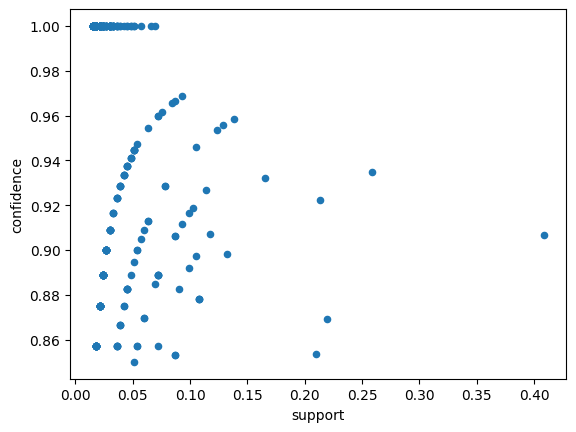

In [19]:
# Scatter plot: rule support (X-axis) vs rule confidence (Y-axis)
reglas_asociacion.plot.scatter('support', 'confidence')
plt.show()

Indeed, what we find interesting or not may vary depending on our objective. Hence, if we were interested in discovering subgroups of very minority patients in which certain conditions are always met, we might pay special attention to the group of rules in the upper left corner of the graph with a confidence 1 but with low or very low supports.

The rules with the highest levels of support are likely to consist of itemsets that are quite frequent in the dataset and probably establish very general relationships that may not add much value. There are likely to be interesting rules among the bulk of rules with medium or low supports. This is because these represent associations that are difficult to detect with the naked eye but that occur in a sufficiently representative number of patients to be interesting for analysis.


Several types of visualizations can be used to study the rules and can help us to summarize the information by providing us with an immediate initial idea of what the rules are telling us. An example would be the “parallel categories“ type graph that we are going to generate below.

In [20]:
# To be able to generate the graph, we convert the elements in
# 'antecedents' y 'consequents' columns from frozensets to lists
reglas_asociacion['antecedents'] = reglas_asociacion['antecedents'].apply(lambda x: list(x))
reglas_asociacion['consequents'] = reglas_asociacion['consequents'].apply(lambda x: list(x))

print()

In [21]:
# Generating a parallel categories graph

# Importing the required libraries
import plotly.graph_objects as go
import plotly.express as px
import numpy as np

# Defining the color palette
colores_px = px.colors.qualitative.Pastel1+px.colors.qualitative.Pastel
# Listing all the items in the transaction set
lista_items = np.array(transacciones.columns)

lista_auxiliar = []
colores = []
for indice,regla in reglas_asociacion.iterrows():
  for ant_item in regla['antecedents']:
    consecuente = regla['consequents'][0]
    lista_auxiliar.append([ant_item, consecuente])
    colores.append(colores_px[np.where(lista_items == consecuente)[0][0]])

df_auxiliar = pd.DataFrame(lista_auxiliar, columns=['Antecedente', 'Consecuente'])

# Creating antecedents dimension
antecedent_dim = go.parcats.Dimension(
    values=df_auxiliar.Antecedente,
    label="Antecedente"
)

# And consequent dimension
consequent_dim = go.parcats.Dimension(
    values=df_auxiliar.Consecuente,
    label="Consecuente"
)

# Creating figure
fig = go.Figure(data = [go.Parcats(dimensions=[antecedent_dim, consequent_dim],
        hoveron='category', hoverinfo='count',
        line={'color':colores},
        labelfont={'size': 14, 'family': 'Arial'},
        arrangement='freeform')])

# Setting fontsize, style and margins
fig.update_layout(
    font=dict(
        family="Arial, monospace",
        size=12,
        color="#7f7f7f"
    ),
    margin=dict(l=200, r=200, t=20, b=20)
)

# Showing the figure
fig.show()


In this graph the items on the left appear in the antecedent of a rule and on the right are items that appear in a consequent:

*	The greater the number of rules in which the item appears as an antecedent or consequent (as appropriate), the larger the sector of the left or right bar associated with that item.
*	If an item, A, ever appears as part of the antecedent of a rule in whose consequent item, B, appears, a line is drawn from A on the left to B on the right of the graph. The thickness of this line indicates the number of rules in which the item on the left appears simultaneously as part of the antecedent and the one on the right as part of the consequent.


Graphs like this one allow us to summarize a lot of information and to easily see, for example, the predominance of the "UV-signature=UV signature" item in the rule consequents. As we have already seen, this item has very high level of support and, therefore, rules with a high level of confidence can be obtained with almost any antecedent.

Thus, focusing on other groups of rules with high confidence values but more specific consequents (with conditions only fulfilled in certain patients), can be much more scientifically interesting. Hence, as an example of one of the many different analyses that could be carried out, in the following we will focus on ARs that try to explain what patients with a particular type of mutation have in common.

###**4.3 Analysis by groups**

We mentioned at the beginning of this capsule that the detection of distinct types of mutations has allowed the development of targeted therapies. One type of approach commonly used in AR analysis is "group analysis". This divides the rules into separate groups depending, for example, on whether they contain certain variables. Thus, we could retain rules in which the variable MUTATIONSUBTYPES appears in the consequent and distinguish between those whose consequent refers to "BRAF_Hotspot_Mutants" or "RAS_Hotspot_Mutants" mutations.

Again, we can rely on visualization tools that allow us to summarize the knowledge contained in the rules and represent it graphically. In this case we will use a chord diagram, also known as a dependency wheel. To generate this type of diagram, we will use the R library *chorddiag* command. Because we need a R library rather than a Python library we must follow the procedure described in previous capsules to use the *rpy2* library we installed at the beginning of the notebook.

To generate a chord diagram we must first create an adjacency matrix. This is a square matrix with as many rows and columns as there are items. For each pair of items, we indicate the number of rules in which the first item is in the antecedent and the second, the number of times it appears in the consequent. In the following cell you can find the code to generate the adjacency matrix corresponding to the rules in whose consequent the BRAF or RAS mutation subtypes appear.

In [22]:
# Importing numpy library with alias np
import numpy as np

# Listing items included in interesting rules
lista_items = []

# We add to lista_items the items in the antecedents and consequents of rules with
# 'MUTATIONSUBTYPES=RAS_Hotspot_Mutants' or 'MUTATIONSUBTYPES=BRAF_Hotspot_Mutants' in their consequents
for indice, regla in reglas_asociacion.iterrows():
  if ('MUTATIONSUBTYPES=RAS_Hotspot_Mutants' in regla['consequents'] or 'MUTATIONSUBTYPES=BRAF_Hotspot_Mutants' in regla['consequents']) and len(regla['consequents']) == 1:
    for con in regla['consequents']: # For each item in the consequent
      if con not in lista_items: # If it had not been already added
        lista_items.append(con) # It is added to lista_items

    for ant in regla['antecedents']: # For each item in the antecedent
      if ant not in lista_items: # If it had not been already added
        lista_items.append(ant) # It is added to lista_items

lista_items = np.array(lista_items)

# Creating and initializing adjacency matrix
matriz_adyacencia_porgrupos = np.zeros((len(lista_items), len(lista_items)), dtype=int)

# For each of the rules
for indice, regla in reglas_asociacion.iterrows():
  # If consequent is one of the interesting items
  if ('MUTATIONSUBTYPES=RAS_Hotspot_Mutants' in regla['consequents'] or 'MUTATIONSUBTYPES=BRAF_Hotspot_Mutants' in regla['consequents']) and len(regla['consequents']) == 1:
    # For each item in the consequent (in our case just one)
    for con in regla['consequents']:
      # Look for its index in lista_items
      pos_consecuente = np.where(lista_items==con)[0][0]
      # For each item in the antecedent
      for ant in regla['antecedents']:
        # Localizamos su posición en lista_items
        pos_antecedente = np.where(lista_items==ant)[0][0]
        # Adding one to the corresponding position in the adjacency matrix
        matriz_adyacencia_porgrupos[pos_consecuente, pos_antecedente] += 1




Once we have generated the adjacency matrix, we can use R to create our chord diagram from that matrix.

Remember that cells beginning with %%R contain R code.

In [23]:
%%R -i matriz_adyacencia_porgrupos -i lista_items

library(chorddiag)

dimnames(matriz_adyacencia_porgrupos) <- list(consecuente = lista_items, antecedente = lista_items)

# Building the chord diagram:
p <- chorddiag(matriz_adyacencia_porgrupos, margin = 250, width=1000, height=1000, palette='Spectral', groupnamePadding = 20, groupnameFontsize = 10, showTicks=FALSE)

# Saving the widget
library(htmlwidgets)
saveWidget(p, file="chordDiagram_porgrupos.html")

In this case, this R code allows us to create a chord diagram stored in the file "chordDiagram_bygroups.html". We can download the file onto our computer by executing the following cell and once downloaded, we can open it in our browser and interact with it.

In [24]:
from google.colab import files
files.download('chordDiagram_porgrupos.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

If you open the downloaded file in your browser, you will see a chart like the one shown below. However, the graph seen here is only a copy of the one we generated (and downloaded) when running the notebook. This means that if we change the notebook code, the downloadable file may also change while the downloaded version shown below will not.

The circumference of the wheel is divided into different sectors which represent the appearances of each item in the consequents of the ARs. The greater the length of the sector reserved for an item, the greater the number of rules in whose consequent it appears; items that do not appear in any consequent are represented by a thin line.

Each of these sectors is divided into different subsectors that link to the items in the antecedents. That is, the "MUTATIONSUBTYPES=RAS_Hotspot_Mutants" sector in the chord diagram contains a subsector that links to the "LYMPHOCYTE.SCORE=0.0" item because "LYMPHOCYTE.SCORE=0.0" appears in the antecedent of the rules with "MUTATIONSUBTYPES=RAS_Hotspot_Mutants" in their consequent. The thickness of the subsector is proportional to the number of rules in which this relationship occurs. In this case, of the 6 rules with "MUTATIONSUBTYPES=RAS_Hotspot_Mutants" in the consequent, 2 included "LYMPHOCYTE.SCORE=0.0" in their antecedent.

In [25]:
from IPython.display import HTML, IFrame
IFrame(src='https://sl.ugr.es/0csy',width=1000, height=500)

Once we know how to interpret it, chord diagrams immediately provide quite a lot of information about our rule subgroups. For example, by hovering our mouse over the two mutation types we can easily detect that only two items appear in the antecedents of both the "LYMPHOCYTE.SCORE=0.0" and "MIRCluster=MIR.type.4"; the remaining items relate only to BRAF-type or RAS-type sub-mutations, but not to both. We can also easily see that the item that appears most often as an antecedent for the BRAF mutation type is "RNASEQ-CLUSTER_CONSENHIER=MITF-low", pointing to an important link between belonging to the MITF-low cluster and having BRAF-type mutations.

In addition, since only a few ARs are included in each cluster, we can afford to look at them in detail and further study the differences between the relationship of both types of mutations and the remaining variables.

Let’s first show each of the rules with the consequent "MUTATIONSUBTYPES=RAS_Hotspot_Mutants":

In [26]:
# Making some adjustments so the rules are shown in a friendly format
# Sorting alphabetically items in both antecedents and consequents
reglas_asociacion['antecedents'].apply(lambda x: x.sort(reverse=False))
reglas_asociacion['consequents'].apply(lambda x: x.sort(reverse=False))

print()

In [27]:
# Index of rules whose consequents includes MUTATIONSUBTYPES=RAS_Hotspot_Mutants
indices_consecuente_RASmut = reglas_asociacion['consequents'].apply(lambda x: 'MUTATIONSUBTYPES=RAS_Hotspot_Mutants' in x and len(x) == 1)
# Selecting only rules whose consequents include MUTATIONSUBTYPES=RAS_Hotspot_Mutants
reglas_consecuente_RASmut = reglas_asociacion.loc[indices_consecuente_RASmut, reglas_asociacion.columns].reset_index()
print('Numer of rules with (MUTATIONSUBTYPES=RAS_Hotspot_Mutants) as consequent: %d' % (len(reglas_consecuente_RASmut)))

# Index of rules whose consequents includes MUTATIONSUBTYPES=BRAF_Hotspot_Mutants
indices_consecuente_BRAFmut = reglas_asociacion['consequents'].apply(lambda x: 'MUTATIONSUBTYPES=BRAF_Hotspot_Mutants' in x and len(x) == 1)
# Selecting only rules whose consequents include MUTATIONSUBTYPES=BRAF_Hotspot_Mutants
reglas_consecuente_BRAFmut = reglas_asociacion.loc[indices_consecuente_BRAFmut, reglas_asociacion.columns].reset_index()
print('Number of rules with (MUTATIONSUBTYPES=BRAF_Hotspot_Mutants) as consequent: %d' % (len(reglas_consecuente_BRAFmut)))

Numer of rules with (MUTATIONSUBTYPES=RAS_Hotspot_Mutants) as consequent: 2
Number of rules with (MUTATIONSUBTYPES=BRAF_Hotspot_Mutants) as consequent: 5


In [28]:
print('>>> Rules with (MUTATIONSUBTYPES=RAS_Hotspot_Mutants) as consequent <<<')
print()
for indice, regla in reglas_consecuente_RASmut.iterrows():
  print('RULE %d' %(indice+1))
  print(regla['antecedents'], ' -----> ', regla['consequents'])
  print('Consequent support: %f' % regla['consequent support'])
  print('Rule support: %f' % regla['support'])
  print('Confidence: %f' % regla['confidence'])
  print('Lift: %f ' % regla['lift'])
  print('Leverage: %f' % regla['leverage'])
  print()

>>> Rules with (MUTATIONSUBTYPES=RAS_Hotspot_Mutants) as consequent <<<

RULE 1
['LYMPHOCYTE.SCORE=0.0', 'MethTypes.201408=CpG island-methylated', 'RNASEQ-CLUSTER_CONSENHIER=immune']  ----->  ['MUTATIONSUBTYPES=RAS_Hotspot_Mutants']
Consequent support: 0.276276
Rule support: 0.021021
Confidence: 1.000000
Lift: 3.619565 
Leverage: 0.015213

RULE 2
['LYMPHOCYTE.SCORE=0.0', 'MIRCluster=MIR.type.4', 'MethTypes.201408=CpG island-methylated']  ----->  ['MUTATIONSUBTYPES=RAS_Hotspot_Mutants']
Consequent support: 0.276276
Rule support: 0.018018
Confidence: 0.857143
Lift: 3.102484 
Leverage: 0.012210



In addition to the consequent, both rules share 2 of the 3 items that form the antecedent "LYMPHOCYTE.SCORE=0.0" and "MethTypes.201408=CpG island-methylated". The difference between the 2 rules is in the use of the "RNASEQ-CLUSTER_CONSENHIER" or "MIRCluster" variable. Because they both have the same consequent, but RULE 1 presents higher confidence, lift, and leverage, it seems that, in this case, the clustering performed to obtain the "RNASEQ-CLUSTER_COSENHIER" variable was more useful for finding a reliable pattern related to the RAS hot-spot mutation.

RULE 1 has relatively low levels of support, meaning that it characterizes a small number of patients (2.1% of the dataset) but offers a confidence of 1 which. This means that there are patients in the dataset for whom we can know their mutation type just by knowing the values of 3 other variables. This group of patients also accounts for about 8% of the total number of patients with a RAS-type mutation, the second most common mutation found in the data. Of course, to extend this rule beyond our dataset we must perform external validation on different sets of patients to confirm that this association holds true in other populations.

Next, we will turn to the rules with the consequent "MUTATIONSUBTYPES=BRAF_Hotspot_Mutants":

In [29]:
print('>>> Rules with (MUTATIONSUBTYPES=BRAF_Hotspot_Mutants) as consequent <<<')
print()
for indice, regla in reglas_consecuente_BRAFmut.iterrows():
  print('RULE %d' %(indice+1))
  print(regla['antecedents'], ' -----> ', regla['consequents'])
  print('Consequent support: %f' % regla['consequent support'])
  print('Rule support: %f' % regla['support'])
  print('Confidence: %f' % regla['confidence'])
  print('Lift: %f ' % regla['lift'])
  print('Leverage: %f' % regla['leverage'])
  print()

>>> Rules with (MUTATIONSUBTYPES=BRAF_Hotspot_Mutants) as consequent <<<

RULE 1
['LYMPHOCYTE.SCORE=0.0', 'MethTypes.201408=hypo-methylated', 'RNASEQ-CLUSTER_CONSENHIER=MITF-low']  ----->  ['MUTATIONSUBTYPES=BRAF_Hotspot_Mutants']
Consequent support: 0.450450
Rule support: 0.018018
Confidence: 1.000000
Lift: 2.220000 
Leverage: 0.009902

RULE 2
['MIRCluster=MIR.type.1', 'RNASEQ-CLUSTER_CONSENHIER=MITF-low']  ----->  ['MUTATIONSUBTYPES=BRAF_Hotspot_Mutants']
Consequent support: 0.450450
Rule support: 0.036036
Confidence: 0.857143
Lift: 1.902857 
Leverage: 0.017098

RULE 3
['MIRCluster=MIR.type.1', 'MethTypes.201408=hypo-methylated', 'RNASEQ-CLUSTER_CONSENHIER=MITF-low']  ----->  ['MUTATIONSUBTYPES=BRAF_Hotspot_Mutants']
Consequent support: 0.450450
Rule support: 0.021021
Confidence: 1.000000
Lift: 2.220000 
Leverage: 0.011552

RULE 4
['MIRCluster=MIR.type.4', 'MethTypes.201408=hyper-methylated', 'RNASEQ-CLUSTER_CONSENHIER=MITF-low']  ----->  ['MUTATIONSUBTYPES=BRAF_Hotspot_Mutants']
Con

All the rules with "MUTATIONSUBTYPES=BRAF_Hotspot_Mutants" in the consequent contain "RNASEQ-CLUSTER_CONSENHIER=MITF-low" in the antecedent. Roughly speaking we can say that, in addition to the MITF-low cluster, BRAF hot-spot mutations also seem to be related to hyper-methylated and hypo-methylated methylation clusters, to type 1 and type 4 MIRClusters, and to low values for lymphocytes.

RULE 2 is the most general one, has the highest level of support, and contains only 2 variables in the antecedent but also has the lowest confidence value. The other 4 rules include the "MethTypes.201408" variable in their priors and have higher confidence values. In fact, the only difference between RULE 2 and RULE 3 is that the latter incorporates the item "MethTypes.201408=hypo-methylated" which allows it to reach a confidence of 1, compared to 0.857 for RULE 2. Therefore, considering whether the instance belongs to the hypo-methylated cluster allows us to more reliably identify a subgroup of patients who will present BRAF-type mutations.

If we continue to pay attention to the "MethTypes.201408" variable we can distinguish, on the one hand, rules 1 and 3 in which the hypo-methylated cluster appears and, on the other hand, rules 4 and 5 in which the hyper-methylated cluster appears. Depending on the rule, the "LYMPHOCYTE.SCORE" variable or the "MIRCluster" variable appears in each subgroup. Thus, as was the case with methylation ("MethTypes.201408"), it appears that microRNA clustering makes it easier to identify a particular subgroup of patients with BRAF-like mutations with greater certainty. This points to two subgroups of patients with BRAF-like mutations belonging to the "MITF-low" cluster and with low levels of lymphocytes:
* Patients for whom low methylation values are observed and are related to the "MIRCluster MIR.type.1"
* Patients for whom high methylation values are observed and are related to the "MIRCluster MIR.type.4"

These results seem to corroborate that the groupings created in the various clustering analyses allowed us to reliably distinguish different patient profiles.

###**4.4 What next?**


This is just one example of the type of AR-based analysis that can be performed on a problem such as the melanoma dataset we are working with in this course. Depending on our specific objective, we may be interested in focusing more on one or another subset of rules or in taking an overview of how the different variables in the dataset are related to each other.

We encourage you to try exploring other subsets of rules that give us information about different subtypes of melanoma patients. Being able to detect different patient profiles and characterize them helps us to understand why patients have different prognoses or react differently to treatments, allowing us to be more effective in choosing the best treatment for each type of patient.

## **BIBLIOGRAPHIC REFERENCES**


*   Pandas library documentation: https://pandas.pydata.org/docs/getting_started/overview.html
*   MLXTEND library code and documentation: http://rasbt.github.io/mlxtend/
*   Matplotlib library documentation: https://matplotlib.org/contents.html
*   Using rpy2 in notebooks: https://rpy2.github.io/doc/latest/html/notebooks.html
*   Plotly Express documentation: https://plotly.com/python/plotly-express/



<div class="alert alert-block alert-success">

MOOC Machine Learning y Big Data para la Bioinformática   
http://abierta.ugr.es     
    
</div>    